Embeddings - 
way to translate words into numerical vectors which computers can understand

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 2D EXAMPLES SAMPLE NOT REAL
word_embeddings = {
    "king":   [0.8, 0.9],
    "queen":  [0.75, 0.85],
    "man":    [0.6, 0.4],
    "woman":  [0.55, 0.35],
    "apple":  [-0.7, -0.8]
}

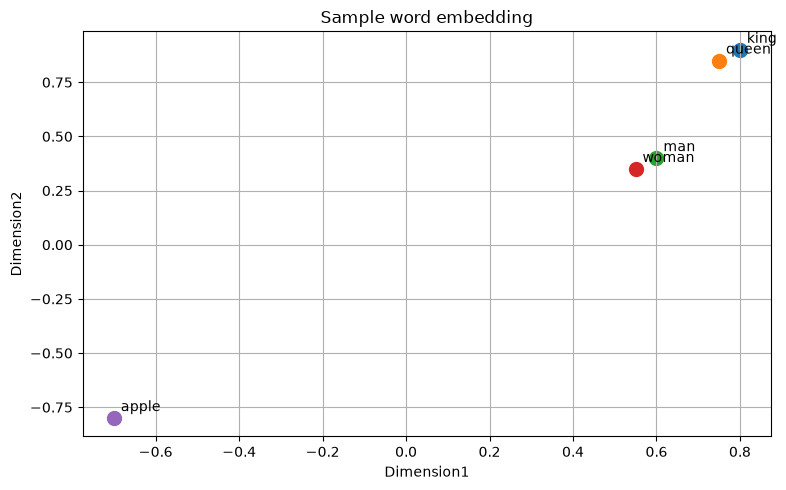

In [3]:
# plotting these vectors
fig,ax = plt.subplots(figsize=(8,5))

for word,cords in word_embeddings.items():
    ax.scatter(cords[0],cords[1],s=100)
    ax.annotate(word,(cords[0],cords[1]),xytext=(5,5), textcoords='offset points')

ax.set_xlabel('Dimension1')
ax.set_ylabel('Dimension2')
ax.set_title('Sample word embedding')
ax.grid(True)

plt.tight_layout()
plt.show()

Measuring Similarity using Cosine Similarity

if result close to 1 -> very similar
   result close to 0 -> not related
   result close to -1 -> opposite meanings

In [4]:
def cosine_similarity(v1,v2):
    dot_product = np.dot(v1,v2)
    norm_a = np.linalg.norm(v1)
    norm_b = np.linalg.norm(v2)
    return dot_product/(norm_a * norm_b)

def get_verdict(result):
    if result >= 0.7:
        return "High relation"
    elif result >= 0.3:
        return "Medium relation"
    elif result >= 0:
        return "Weak relation"
    else:
        return "Dissimilar"

In [5]:
# applying similarity test on sample data
words = list(word_embeddings.items())
for i in range(len(words)):
    word1, vec1 = words[i]
    for j in range(i + 1, len(words)):
        word2, vec2 = words[j]
        similarity = cosine_similarity(vec1, vec2)
        verdict = get_verdict(similarity)
        print(f"{word1} ↔ {word2}: {similarity:.3f} -> {verdict}")

king ↔ queen: 1.000 -> High relation
king ↔ man: 0.967 -> High relation
king ↔ woman: 0.962 -> High relation
king ↔ apple: -1.000 -> Dissimilar
queen ↔ man: 0.966 -> High relation
queen ↔ woman: 0.961 -> High relation
queen ↔ apple: -1.000 -> Dissimilar
man ↔ woman: 1.000 -> High relation
man ↔ apple: -0.965 -> Dissimilar
woman ↔ apple: -0.960 -> Dissimilar


CREATING EMBEDDINGS

In [6]:
from langchain_huggingface import HuggingFaceEmbeddings

# initializing simple embedding model
embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)
embeddings

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [7]:
# sample test
text = "Hello, I am learning about embeddings"
result = embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding: {result}")
print(f"Length of embedding: {len(result)}")

Text: Hello, I am learning about embeddings
Embedding: [-0.01666160300374031, -0.09771719574928284, 0.0019201628165319562, -0.0016134491888806224, 0.014046636410057545, 0.0608392171561718, 0.01228360552340746, 0.015745390206575394, 0.04093797877430916, -0.030124597251415253, 0.02626509964466095, 0.06559295207262039, 0.045701734721660614, 0.008897011168301105, -0.04620596393942833, 0.019462624564766884, 0.04677308350801468, 0.07357393205165863, -0.07927095144987106, -0.006600834894925356, -0.03383966535329819, -0.046639181673526764, 0.010644786059856415, -0.09673543274402618, 0.024105308577418327, -0.025333048775792122, -0.02141120657324791, 0.05911486968398094, 0.10023824125528336, -0.060241520404815674, 0.03970739617943764, -0.03374629467725754, -0.01957436092197895, 0.06622900813817978, -0.06176459789276123, 0.1168927475810051, 0.039554208517074585, -0.0030686217360198498, -0.08189611881971359, -0.003654164494946599, 0.028080934658646584, 0.025156399235129356, -0.02704869583249092, 0

In [8]:
# embedding multiple sentences
sentences = [
    "The cat slept on the sofa.",
    "A boy kicked the football.",
    "The sun shines brightly today.",
    "She drank a cup of tea.",
    "Birds flew across the sky."
]

result = embeddings.embed_documents(sentences)
print(type(result))
print(type(result[0]))
print(result)

<class 'list'>
<class 'list'>
[[0.15316841006278992, -0.04353371635079384, -0.039088621735572815, 0.06439180672168732, 0.0040522292256355286, 0.042998094111680984, -0.03749779239296913, -0.011489438824355602, 0.020099734887480736, 0.032770927995443344, -0.09954772889614105, 0.06509220600128174, -0.004642648622393608, 0.06522859632968903, -0.05432360991835594, 0.0229131318628788, -0.09300980716943741, -0.02912234328687191, 0.05750604346394539, 0.05288933962583542, 0.01679539866745472, 0.01879826933145523, 0.031635407358407974, -0.04735272377729416, 0.006520536262542009, -0.0005551057984121144, -0.03813929855823517, -0.08147672563791275, -0.029451634734869003, -0.00289873406291008, -0.03713779151439667, -0.024408450350165367, -0.02829347737133503, -0.0010514315217733383, -0.025969717651605606, -0.04702543467283249, -0.0004893076256848872, -0.03892625868320465, -0.027694175019860268, 0.14776194095611572, 0.02248487062752247, -0.00805306900292635, -0.015529888682067394, 0.00195410102605819

SEMANTIC SEARCH WORKING EXAMPLE

In [14]:
sentences = [
    "The Eiffel Tower is located in Paris, France.",
    "Python is a popular programming language used for data science.",
    "The Pacific Ocean is the largest ocean on Earth.",
    "Regular exercise can improve both physical and mental health.",
    "Mount Everest is the highest mountain above sea level."
]

query = "What is the largest ocean on Earth?"

In [15]:
# simple semantic search
def semantic_search(query,documents,embeddings_models,top_k=3):
    # top_k = no of similar sentence the search will return (here top 3)
    query_embedding = embeddings_models.embed_query(query)
    doc_embeddings = embeddings_models.embed_documents(documents)

    # calculating and storing similarity score
    similarities = []

    for i,doc_emb in enumerate(doc_embeddings):
        similarity = cosine_similarity(query_embedding,doc_emb)
        similarities.append((similarity,documents[i]))
    
    # sorting wrt to similarity
    similarities.sort(reverse=True)
    return similarities[:top_k]

In [16]:
result_new = semantic_search(query,sentences,embeddings)
for score,doc in result_new:
    print(f"Score: {score:.3f} | {doc}")

Score: 0.806 | The Pacific Ocean is the largest ocean on Earth.
Score: 0.358 | Mount Everest is the highest mountain above sea level.
Score: 0.101 | Python is a popular programming language used for data science.
